<a href="https://colab.research.google.com/github/pramaspx/Regresi_5C_Kelompok_6/blob/main/Kelompok6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [290]:
# 1. Import Library yang Dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [291]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries berhasil dimuat!")

Libraries berhasil dimuat!


In [292]:
# 2. Memuat Dataset
df = pd.read_csv('CAR DETAILS FROM CAR DEKHO.csv')

In [293]:
# Menampilkan 5 baris pertama dataset
print("--- 5 Baris Pertama Dataset ---")
display(df.head())

--- 5 Baris Pertama Dataset ---


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [294]:
# 3. Exploratory Data Analysis (EDA) Sederhana
print("\n--- Informasi Dataset ---")
print(df.info())


--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB
None


In [295]:
print("\n--- Statistik Deskriptif ---")
display(df.describe())


--- Statistik Deskriptif ---


,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [296]:
print("\n--- Pengecekan Missing Value ---")
print(df.isnull().sum())


--- Pengecekan Missing Value ---
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


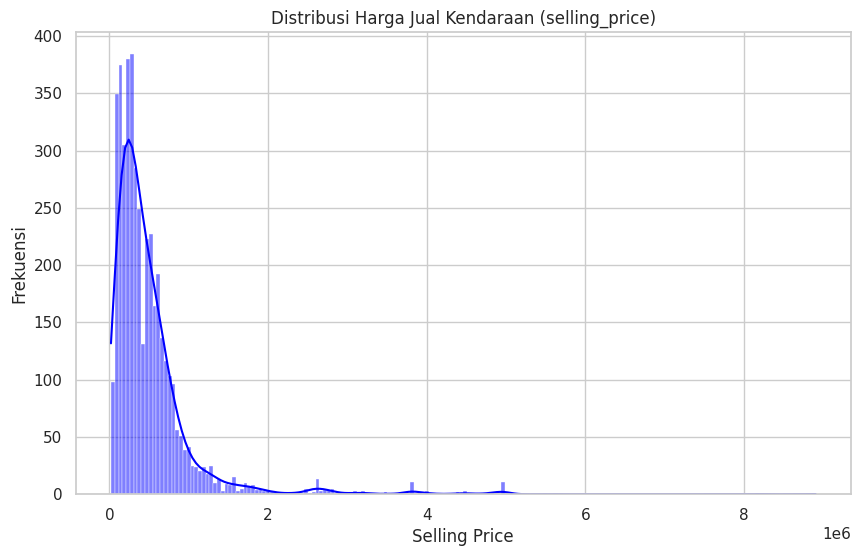

In [297]:
plt.figure()
sns.histplot(df['selling_price'], kde=True, color='blue')
plt.title('Distribusi Harga Jual Kendaraan (selling_price)')
plt.xlabel('Selling Price')
plt.ylabel('Frekuensi')
plt.show()

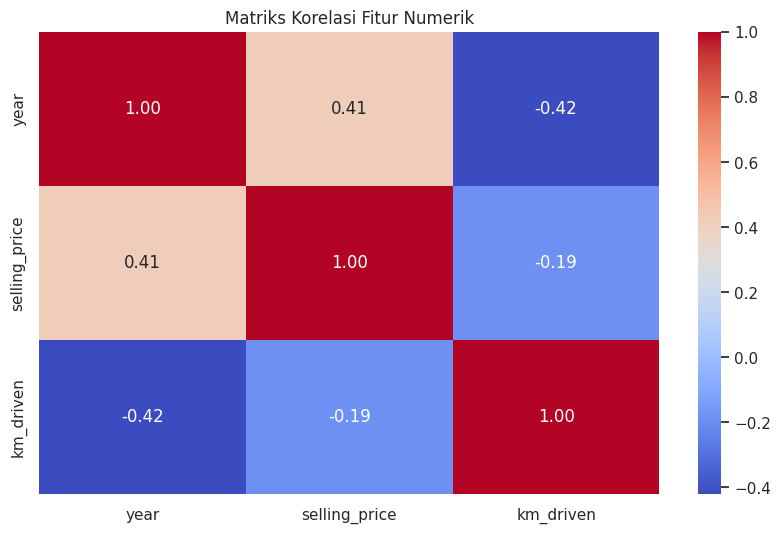

In [298]:
plt.figure()
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriks Korelasi Fitur Numerik')
plt.show()

In [299]:
# 4. Feature Engineering: Mengubah Tahun Menjadi Umur Kendaraan
current_year = 2026

# Sesuaikan nama kolom tahun jika berbeda di dalam file CSV (misal: 'Year' atau 'year')
year_column = 'year' if 'year' in df.columns else 'Year'

if year_column in df.columns:
    df['Vehicle_Age'] = current_year - df[year_column]
    df = df.drop(columns=[year_column])
    print(f"\nKolom '{year_column}' berhasil diubah menjadi 'Vehicle_Age'.")


Kolom 'year' berhasil diubah menjadi 'Vehicle_Age'.


In [300]:
# 5. Preprocessing & Encoding Spesifikasi Kendaraan
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Kolom kategorikal yang akan di-encode: {categorical_cols}")

Kolom kategorikal yang akan di-encode: ['name', 'fuel', 'seller_type', 'transmission', 'owner']


In [309]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [308]:
# 6. Menentukan Fitur (X) dan Target (y)
target_column = 'selling_price'
if target_column in df_encoded.columns:
    X = df_encoded.drop(columns=[target_column])
    # Hapus kolom tahun asli jika masih ada karena sudah diubah menjadi 'Vehicle_Age'
    if 'year' in X.columns:
        X = X.drop(columns=['year'])
    y = df_encoded[target_column]
else:
    raise ValueError(f"Kolom target '{target_column}' tidak ditemukan di dataset!")

In [303]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Ukuran Data Latih (X_train): {X_train.shape}")
print(f"Ukuran Data Uji (X_test): {X_test.shape}")

Ukuran Data Latih (X_train): (3472, 1503)
Ukuran Data Uji (X_test): (868, 1503)


In [310]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [305]:
model = LinearRegression()
model.fit(X_train, y_train)

# Melakukan prediksi pada data uji
y_pred = model.predict(X_test)

In [306]:
# ==========================================
# 7. EVALUASI MODEL
# ==========================================
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- HASIL EVALUASI REGRESI LINIER ---")
print(f"Mean Squared Error (MSE)  : {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R2 Score (Akurasi Model)  : {r2:.4f}")


--- HASIL EVALUASI REGRESI LINIER ---
Mean Squared Error (MSE)  : 121717437751.3837
Root Mean Squared Error (RMSE): 348880.2628
R2 Score (Akurasi Model)  : 0.6011


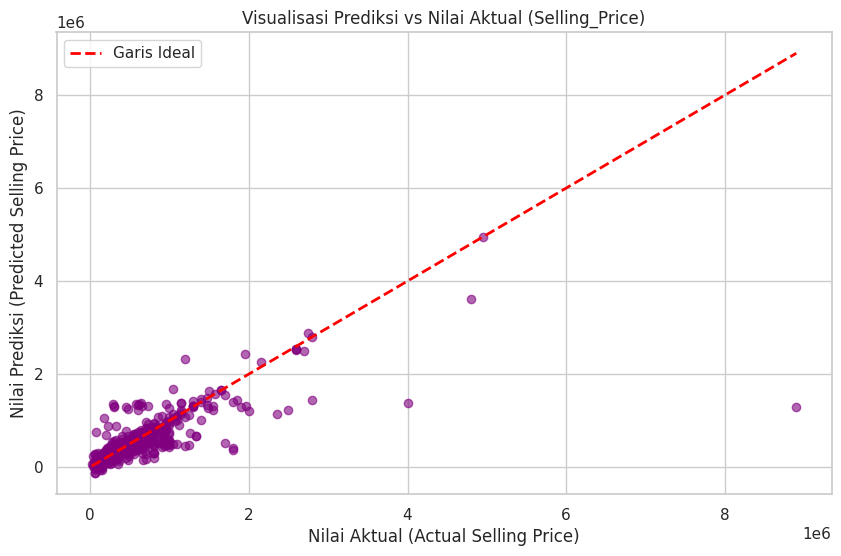

In [307]:
plt.figure()
plt.scatter(y_test, y_pred, color='purple', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--', label='Garis Ideal')
plt.title('Visualisasi Prediksi vs Nilai Aktual (Selling_Price)')
plt.xlabel('Nilai Aktual (Actual Selling Price)')
plt.ylabel('Nilai Prediksi (Predicted Selling Price)')
plt.legend()
plt.show()